In [1]:
import logging
import shutil
import subprocess
import tempfile
from functools import lru_cache
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

logging.getLogger("fontTools.ttLib.tables._h_e_a_d").setLevel(logging.ERROR)

FORCE_TEX = True
BASE_FONT_SIZE = 16
AXIS_LABEL_SIZE = 18
AXIS_TITLE_SIZE = 18
TICK_LABEL_SIZE = 16
LEGEND_FONT_SIZE = 13
VALUE_LABEL_FONT_SIZE = 13
DEFAULT_FIGSIZE = (8.4, 4.8)
COMPARISON_FIGSIZE = (13.2, 4.4)

ORDER = ["Safe", "Unknown", "Unsafe"]

SERIES_ORDER = [
    r"$\alpha\beta$-CROWN",
    r"$\alpha\beta$-CROWN w/ CSI [object]",
    r"$\alpha\beta$-CROWN w/ CSI [background]",
]

SERIES_LABELS = [
    "Whole Image",
    "Object",
    "Background",
]
OUTCOME_STYLE = {
    "Safe": {"facecolor": "#111111", "hatch": ""},
    "Unknown": {"facecolor": "white", "hatch": "///"},
    "Unsafe": {"facecolor": "#B22222", "hatch": "xx"},
}


def map_result_to_outcome(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    if value.startswith("unsat"):
        return "Safe"
    if value.startswith("timeout"):
        return "Unknown"
    if value.startswith("sat"):
        return "Unsafe"
    return "Other"


def normalize_tag(value):
    value = str(value).strip().lower()
    return value.replace("fixnonmask", "fix_nonmask").replace("fixmask", "fix_mask")


@lru_cache(maxsize=1)
def latex_ready():
    required_commands = ("latex", "dvipng")
    if any(shutil.which(command) is None for command in required_commands):
        return False

    if shutil.which("kpsewhich") is not None:
        latex_fmt = subprocess.run(
            ["kpsewhich", "latex.fmt"],
            capture_output=True,
            text=True,
            check=False,
        )
        if latex_fmt.returncode != 0 or not latex_fmt.stdout.strip():
            return False

    latex_source = "\n".join([
        r"\documentclass{article}",
        r"\begin{document}",
        r"lp",
        r"\end{document}",
    ])

    with tempfile.TemporaryDirectory() as tmpdir:
        tex_path = Path(tmpdir) / "matplotlib_tex_probe.tex"
        tex_path.write_text(latex_source, encoding="utf-8")
        result = subprocess.run(
            ["latex", "-interaction=nonstopmode", "--halt-on-error", tex_path.name],
            cwd=tmpdir,
            capture_output=True,
            text=True,
            check=False,
        )
        return result.returncode == 0 and (Path(tmpdir) / "matplotlib_tex_probe.dvi").exists()


def has_tex_package(package_name):
    if shutil.which("kpsewhich") is None:
        return False
    return subprocess.run(
        ["kpsewhich", f"{package_name}.sty"],
        capture_output=True,
        text=True,
        check=False,
    ).returncode == 0


@lru_cache(maxsize=2)
def configure_plot_style(force_tex=FORCE_TEX):
    use_tex = force_tex and latex_ready()
    preamble = r"\usepackage{fontawesome5}" if use_tex and has_tex_package("fontawesome5") else ""

    if force_tex and not use_tex:
        print(
            "LaTeX was requested but the current environment cannot compile a minimal "
            "TeX document. Falling back to Matplotlib serif text."
        )

    mpl.rcParams.update({
        "text.usetex": use_tex,
        "font.family": "serif",
        "font.serif": [
            "Times New Roman",
            "Times",
            "Nimbus Roman",
            "STIXGeneral",
            "DejaVu Serif",
        ],
        "mathtext.fontset": "cm",
        "text.latex.preamble": preamble,
        "font.size": BASE_FONT_SIZE,
        "axes.labelsize": AXIS_LABEL_SIZE,
        "axes.titlesize": AXIS_TITLE_SIZE,
        "xtick.labelsize": TICK_LABEL_SIZE,
        "ytick.labelsize": TICK_LABEL_SIZE,
        "legend.fontsize": LEGEND_FONT_SIZE,
        "axes.linewidth": 1.0,
        "grid.linewidth": 0.6,
        "hatch.linewidth": 0.9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    return use_tex


def load_outcome_counts(csv_path, k_value):
    df = pd.read_csv(csv_path).copy()
    df["tag_norm"] = df["tag"].apply(normalize_tag)
    df["k"] = pd.to_numeric(df["k"], errors="coerce")
    if "is_global" in df.columns:
        df["is_global"] = pd.to_numeric(df["is_global"], errors="coerce").fillna(0)
    else:
        df["is_global"] = 0
    df["outcome"] = df["result"].apply(map_result_to_outcome)

    df = df[(df["k"] == k_value) & df["outcome"].isin(ORDER)].copy()

    grouped = {
        SERIES_ORDER[0]: df[(df["tag_norm"] == "global") | (df["is_global"] == 1)],
        SERIES_ORDER[1]: df[df["tag_norm"] == "fix_nonmask"],
        SERIES_ORDER[2]: df[df["tag_norm"] == "fix_mask"],
    }

    counts = {
        label: group["outcome"].value_counts().reindex(ORDER, fill_value=0)
        for label, group in grouped.items()
    }

    summary = pd.DataFrame({label: counts[label] for label in SERIES_ORDER}, index=ORDER)
    return summary


def annotate_bars(ax, bars, label_offset):
    for bar in bars:
        height = bar.get_height()
        if height <= 0:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + label_offset,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=VALUE_LABEL_FONT_SIZE,
        )


def outcome_legend_handles():
    return [
        Patch(
            facecolor=OUTCOME_STYLE[outcome]["facecolor"],
            edgecolor="black",
            hatch=OUTCOME_STYLE[outcome]["hatch"],
            label=outcome,
        )
        for outcome in ORDER
    ]


def plot_outcome_counts(csv_path, k_value, output_path, dataset_label, figsize=DEFAULT_FIGSIZE, show_legend=True, title=None):
    configure_plot_style()
    summary = load_outcome_counts(csv_path, k_value)
    plot_data = summary.T.reindex(SERIES_ORDER)[ORDER]

    print(f"{dataset_label} (k={k_value})")
    print(summary)

    x = np.arange(len(SERIES_ORDER))
    width = 0.22
    offsets = width * np.array([-1, 0, 1])
    ymax = max(int(plot_data.to_numpy().max()), 1)
    label_offset = max(1.2, 0.025 * ymax)

    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    for offset, outcome in zip(offsets, ORDER):
        style = OUTCOME_STYLE[outcome]
        bars = ax.bar(
            x + offset,
            plot_data[outcome].values,
            width=width,
            color=style["facecolor"],
            edgecolor="black",
            linewidth=1.1,
            hatch=style["hatch"],
            zorder=3,
        )
        annotate_bars(ax, bars, label_offset)

    ax.set_xticks(x)
    ax.set_xticklabels(SERIES_LABELS)
    ax.set_ylabel("Number of Instances")
    if title is None:
        title = dataset_label
    if title:
        ax.set_title(title, fontsize=AXIS_TITLE_SIZE, pad=10)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.55)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.tick_params(axis="x", length=0, pad=8)
    ax.margins(x=0.08)
    ax.set_ylim(0, ymax * 1.18 + 2.2 * label_offset)
    if show_legend:
        ax.legend(
            handles=outcome_legend_handles(),
            frameon=False,
            ncol=3,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.02),
            handlelength=1.8,
            columnspacing=1.4,
            borderaxespad=0.0,
        )

    fig.tight_layout()
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()

    return summary


LaTeX was requested but the current environment cannot compile a minimal TeX document. Falling back to Matplotlib serif text.
CIFAR-100 (k=1024)
         $\alpha\beta$-CROWN  $\alpha\beta$-CROWN w/ CSI [object]  \
Safe                     103                                  151   
Unknown                   72                                   31   
Unsafe                    25                                   18   

         $\alpha\beta$-CROWN w/ CSI [background]  
Safe                                         200  
Unknown                                        0  
Unsafe                                         0  


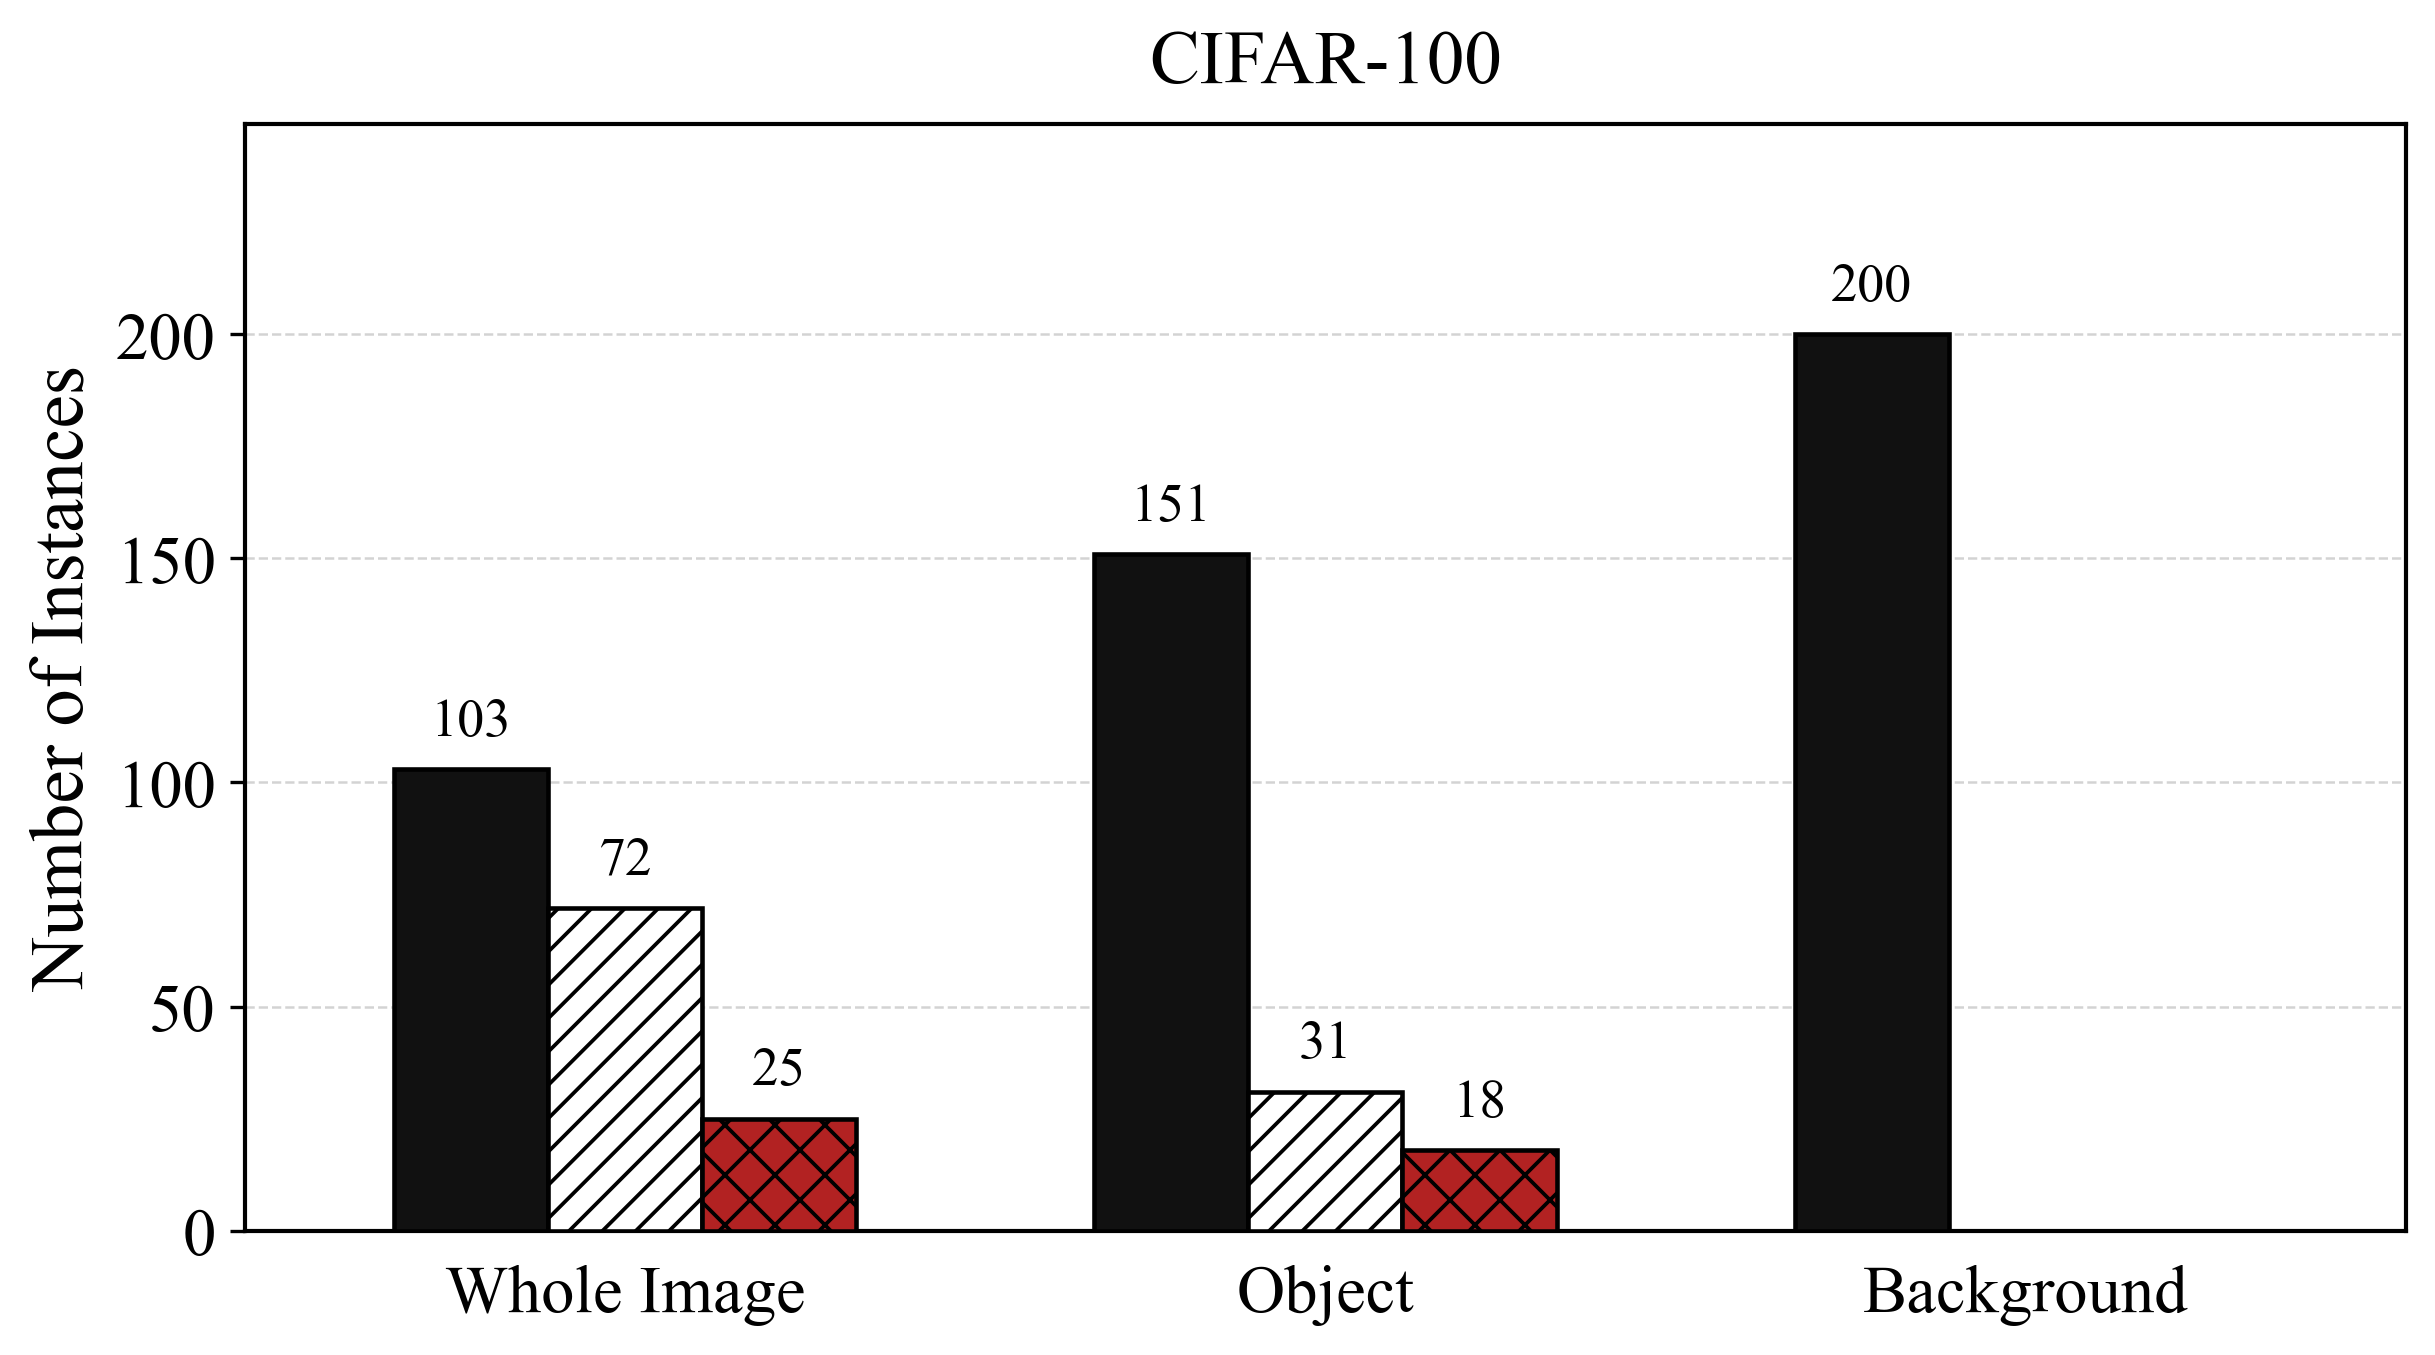

,$\alpha\beta$-CROWN,$\alpha\beta$-CROWN w/ CSI [object],$\alpha\beta$-CROWN w/ CSI [background]
Safe,103,151,200
Unknown,72,31,0
Unsafe,25,18,0


In [2]:
cifar_summary = plot_outcome_counts(
    csv_path="../../results/cifar100/cifar100_CSI.csv",
    k_value=1024,
    output_path="result_cifar.pdf",
    dataset_label="CIFAR-100",
    show_legend=False,
)
cifar_summary


ImageNet (k=50176)
         $\alpha\beta$-CROWN  $\alpha\beta$-CROWN w/ CSI [object]  \
Safe                      13                                   58   
Unknown                   72                                   28   
Unsafe                    96                                   95   

         $\alpha\beta$-CROWN w/ CSI [background]  
Safe                                          68  
Unknown                                       18  
Unsafe                                        95  


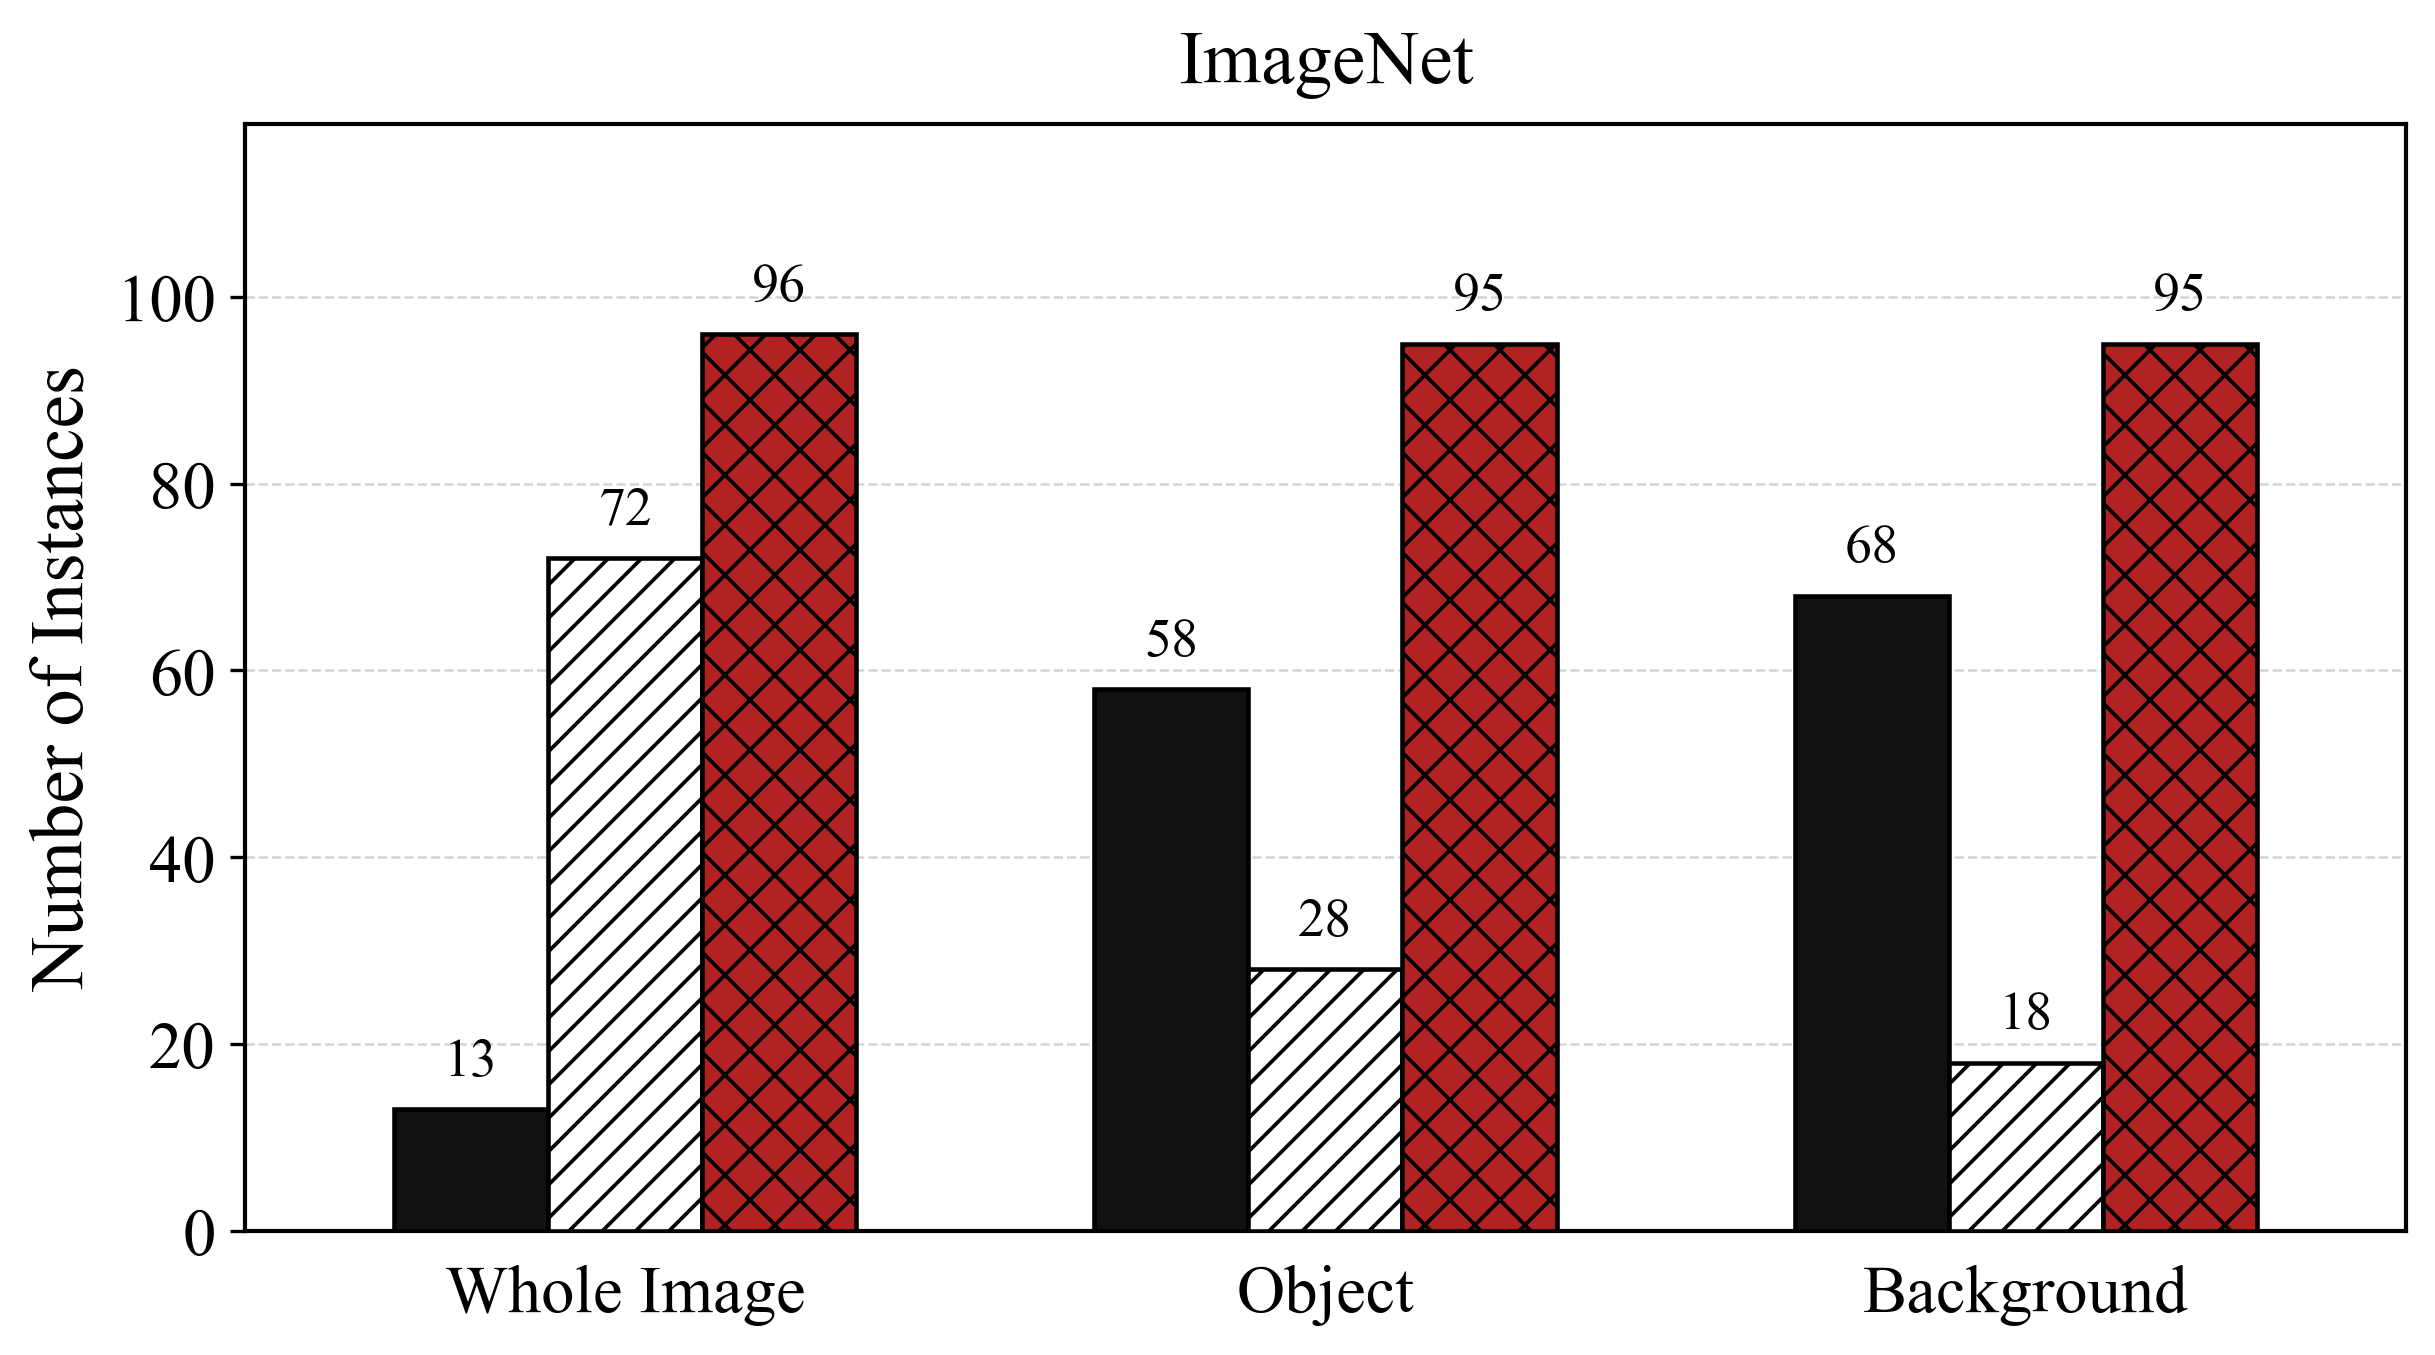

,$\alpha\beta$-CROWN,$\alpha\beta$-CROWN w/ CSI [object],$\alpha\beta$-CROWN w/ CSI [background]
Safe,13,58,68
Unknown,72,28,18
Unsafe,96,95,95


In [3]:
imagenet_summary = plot_outcome_counts(
    csv_path="../../results/vggnet16/all_k_vggnet16.csv",
    k_value=50176,
    output_path="result_imagenet.pdf",
    dataset_label="ImageNet",
    show_legend=False,
)
imagenet_summary


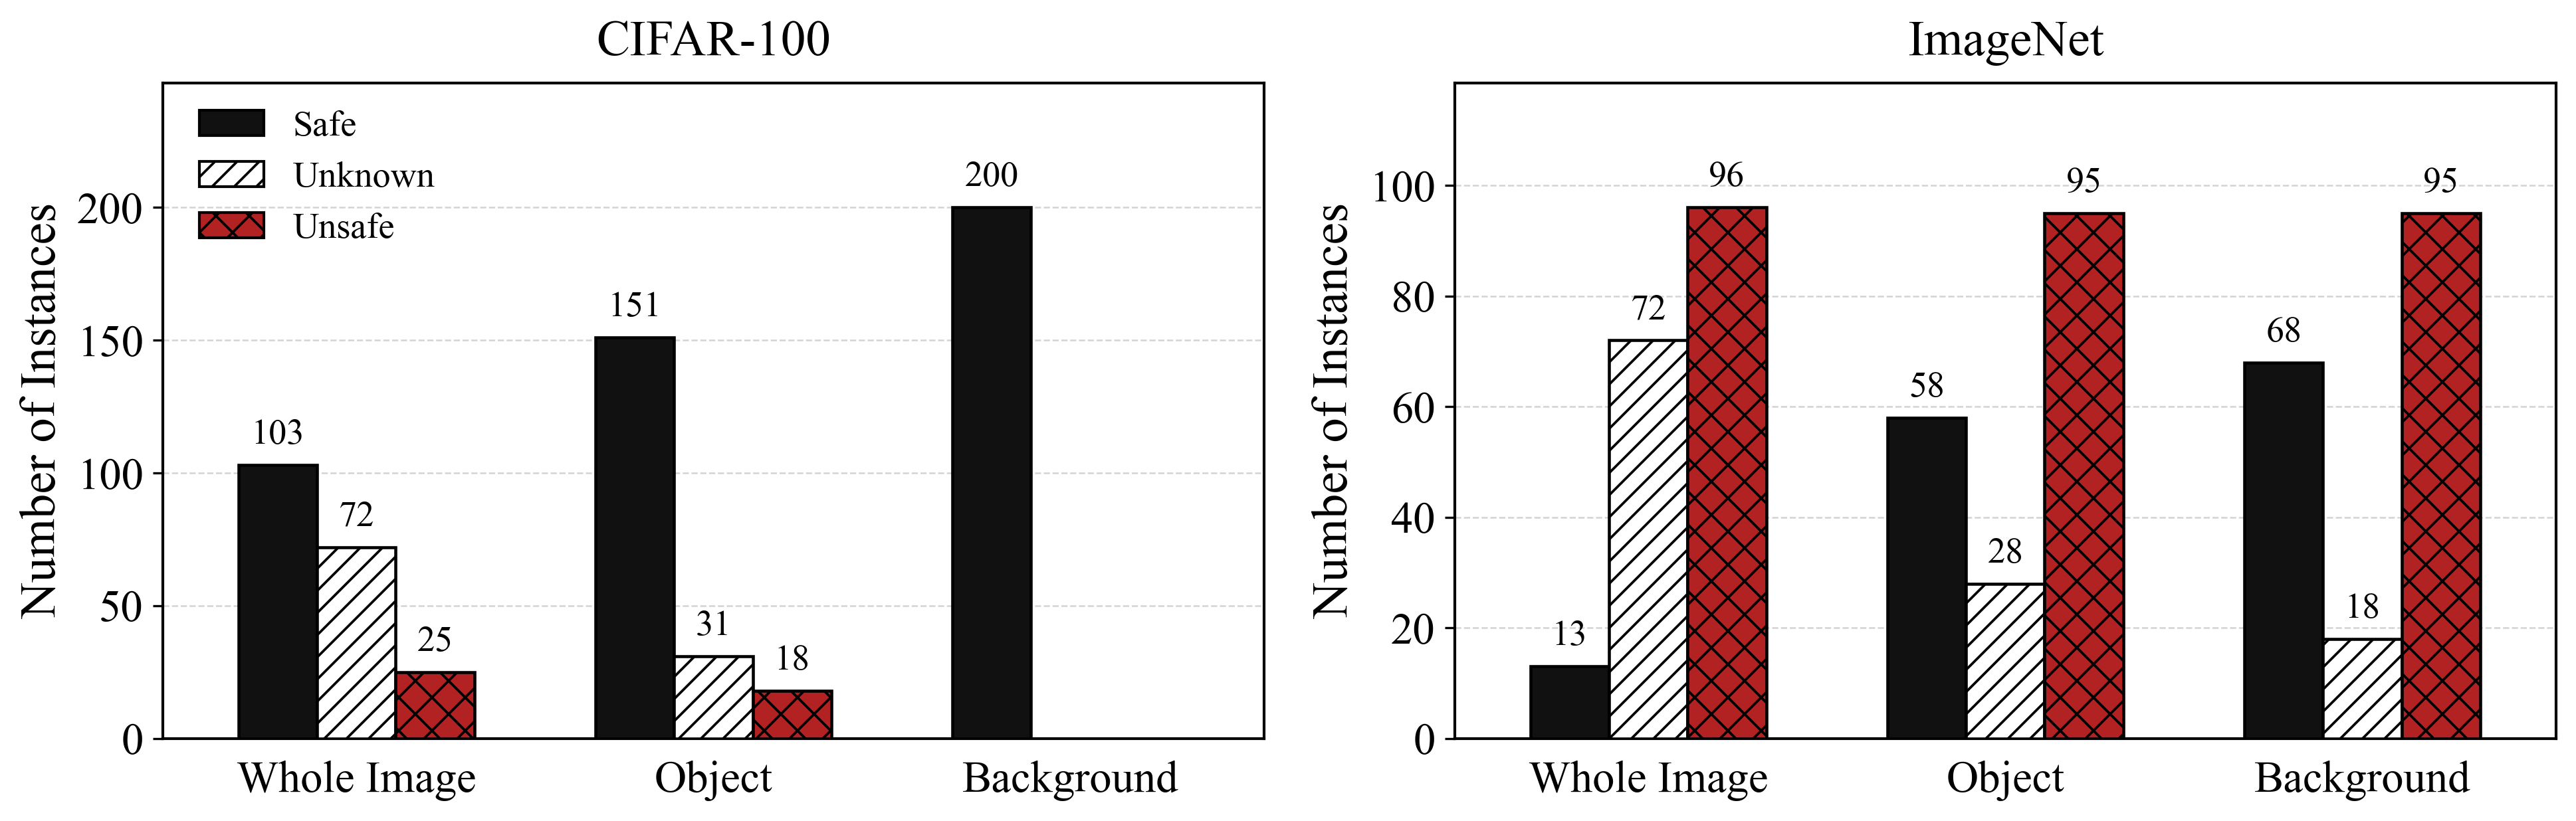

In [4]:
configure_plot_style()

comparison_specs = [
    ("../../results/cifar100/cifar100_CSI.csv", 1024, "CIFAR-100"),
    ("../../results/vggnet16/all_k_vggnet16.csv", 50176, "ImageNet"),
]

fig, axes = plt.subplots(1, 2, figsize=COMPARISON_FIGSIZE, dpi=300)

for ax, (csv_path, k_value, dataset_label) in zip(axes, comparison_specs):
    summary = load_outcome_counts(csv_path, k_value)
    plot_data = summary.T.reindex(SERIES_ORDER)[ORDER]

    x = np.arange(len(SERIES_ORDER))
    width = 0.22
    offsets = width * np.array([-1, 0, 1])
    ymax = max(int(plot_data.to_numpy().max()), 1)
    label_offset = max(1.2, 0.025 * ymax)

    for offset, outcome in zip(offsets, ORDER):
        style = OUTCOME_STYLE[outcome]
        bars = ax.bar(
            x + offset,
            plot_data[outcome].values,
            width=width,
            color=style["facecolor"],
            edgecolor="black",
            linewidth=1.1,
            hatch=style["hatch"],
            zorder=3,
        )
        annotate_bars(ax, bars, label_offset)

    ax.set_xticks(x)
    ax.set_xticklabels(SERIES_LABELS)
    ax.set_ylabel("Number of Instances")
    ax.set_title(dataset_label, fontsize=AXIS_TITLE_SIZE, pad=10)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.55)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.tick_params(axis="x", length=0, pad=8)
    ax.margins(x=0.08)
    ax.set_ylim(0, ymax * 1.18 + 2.2 * label_offset)

axes[0].legend(
    handles=outcome_legend_handles(),
    frameon=False,
    ncol=1,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    handlelength=1.8,
    borderaxespad=0.0,
)
fig.tight_layout()
fig.savefig("result_imagenet_vs_cifar100.pdf", bbox_inches="tight")
plt.show()
